# Exploratory Data Analysis

This notebook profiles the synthetic Nepali e-commerce dataset used for the hybrid recommendation thesis experiments.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from recommender.utils import load_data

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 50)

products, users, interactions = load_data()
interactions["timestamp"] = pd.to_datetime(interactions["timestamp"])

print("Data loaded successfully")
display(products.head())
display(users.head())
display(interactions.head())

Data loaded successfully


,product_id,name,category,subcategory,brand,description,price_npr,avg_rating,rating_count,tags,is_new_arrival,in_stock
0,P0001,Himalaya Bags 1,Fashion & Accessories,Bags,Himalaya,Bags made for Nepali shoppers with reliable qu...,899,4.6,324,"fashion & accessories, bags, nepal, himalaya, ...",True,True
1,P0002,Kathmandu Craft Jewellery 2,Fashion & Accessories,Jewellery,Kathmandu Craft,Jewellery made for Nepali shoppers with reliab...,6500,4.0,335,"fashion & accessories, jewellery, nepal, kathm...",False,True
2,P0003,Janakpur Mart Woodcraft 3,Handicrafts & Art,Woodcraft,Janakpur Mart,Woodcraft made for Nepali shoppers with reliab...,350,4.2,339,"handicrafts & art, woodcraft, nepal, janakpur ...",True,True
3,P0004,NepTech Daura Suruwal 4,Traditional Attire,Daura Suruwal,NepTech,Daura Suruwal made for Nepali shoppers with re...,550,4.5,162,"traditional attire, daura suruwal, nepal, nept...",False,True
4,P0005,Himalaya Cookware 5,Kitchen & Home,Cookware,Himalaya,Cookware made for Nepali shoppers with reliabl...,350,4.3,267,"kitchen & home, cookware, nepal, himalaya, gift",False,True


,user_id,name,city,age,gender,user_type,preferred_categories,joined_date,is_verified
0,U0001,Customer 1,Butwal,29,other,power,Books & Education|Daily Groceries,2024-04-20,True
1,U0002,Customer 2,Butwal,38,other,power,Daily Groceries|Traditional Attire,2023-06-05,True
2,U0003,Customer 3,Pokhara,50,male,power,Electronics|Traditional Attire,2024-11-05,False
3,U0004,Customer 4,Lalitpur,35,male,new,Books & Education|Electronics,2023-11-10,True
4,U0005,Customer 5,Butwal,40,other,regular,Handicrafts & Art|Books & Education,2023-06-25,True


,interaction_id,user_id,product_id,interaction_type,rating,implicit_score,timestamp,month,is_festival_period
0,I00001,U0030,P0420,purchase,NaN,4.0,2024-12-08,12,False
1,I00002,U0206,P0130,cart,NaN,2.0,2024-04-21,4,False
2,I00003,U0047,P0150,view,NaN,1.0,2024-07-03,7,False
3,I00004,U0022,P0465,view,NaN,1.0,2025-05-18,5,False
4,I00005,U0149,P0277,view,NaN,1.0,2024-07-31,7,False


## Dataset Shape

In [2]:
shape_summary = pd.DataFrame(
    {
        "dataset": ["products", "users", "interactions"],
        "rows": [len(products), len(users), len(interactions)],
        "columns": [products.shape[1], users.shape[1], interactions.shape[1]],
    }
)
display(shape_summary)
print(
    f"The dataset contains {len(products):,} products, {len(users):,} users, "
    f"and {len(interactions):,} interaction events."
)

,dataset,rows,columns
0,products,500,12
1,users,300,9
2,interactions,6194,9


The dataset contains 500 products, 300 users, and 6,194 interaction events.


## Interaction Type Breakdown

In [3]:
interaction_breakdown = (
    interactions["interaction_type"]
    .value_counts()
    .rename_axis("interaction_type")
    .reset_index(name="count")
)
interaction_breakdown["share"] = interaction_breakdown["count"] / len(interactions)
display(interaction_breakdown)

for row in interaction_breakdown.itertuples(index=False):
    print(f"{row.interaction_type}: {row.count:,} interactions ({row.share:.1%})")

,interaction_type,count,share
0,view,3494,0.564094
1,cart,1246,0.201162
2,purchase,943,0.152244
3,rating,511,0.082499


view: 3,494 interactions (56.4%)
cart: 1,246 interactions (20.1%)
purchase: 943 interactions (15.2%)
rating: 511 interactions (8.2%)


## User-Item Matrix Density

In [4]:
possible_pairs = users["user_id"].nunique() * products["product_id"].nunique()
observed_pairs = interactions[["user_id", "product_id"]].drop_duplicates().shape[0]
density = observed_pairs / possible_pairs
sparsity = 1 - density

print(f"Unique observed user-item pairs: {observed_pairs:,}")
print(f"Possible user-item pairs: {possible_pairs:,}")
print(f"User-item matrix density: {density:.4%}")
print(f"User-item matrix sparsity: {sparsity:.4%}")
print(
    "This high sparsity is a core recommendation challenge: most Nepali shoppers "
    "interact with only a small fraction of the catalog, so collaborative filtering "
    "alone has limited signal for many user-product pairs."
)

Unique observed user-item pairs: 6,066
Possible user-item pairs: 150,000
User-item matrix density: 4.0440%
User-item matrix sparsity: 95.9560%
This high sparsity is a core recommendation challenge: most Nepali shoppers interact with only a small fraction of the catalog, so collaborative filtering alone has limited signal for many user-product pairs.


## Top 10 Most Interacted Products

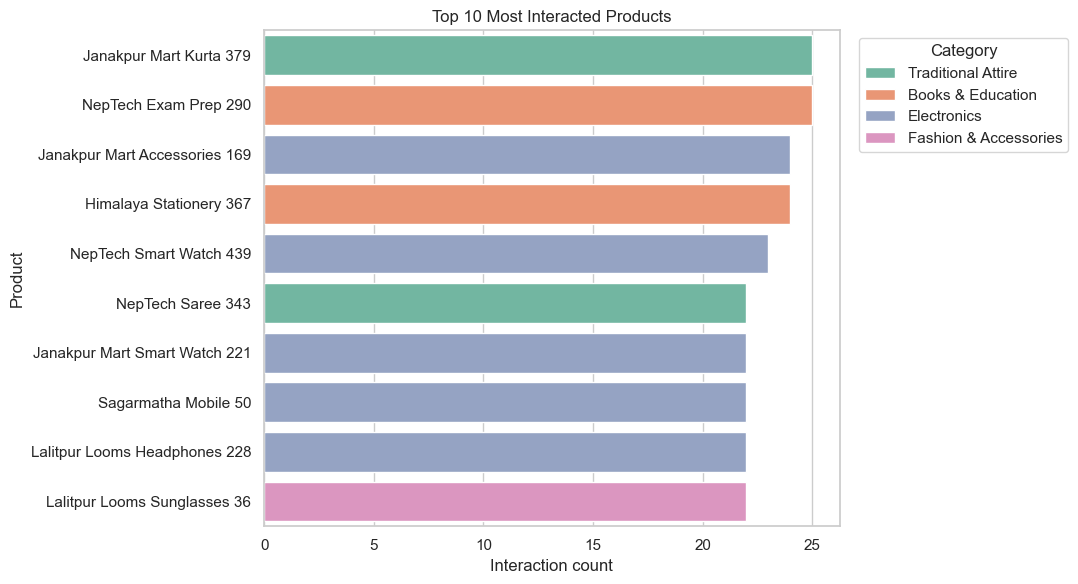

,product_id,interaction_count,name,category
324,P0379,25,Janakpur Mart Kurta 379,Traditional Attire
249,P0290,25,NepTech Exam Prep 290,Books & Education
140,P0169,24,Janakpur Mart Accessories 169,Electronics
315,P0367,24,Himalaya Stationery 367,Books & Education
375,P0439,23,NepTech Smart Watch 439,Electronics
294,P0343,22,NepTech Saree 343,Traditional Attire
184,P0221,22,Janakpur Mart Smart Watch 221,Electronics
39,P0050,22,Sagarmatha Mobile 50,Electronics
191,P0228,22,Lalitpur Looms Headphones 228,Electronics
27,P0036,22,Lalitpur Looms Sunglasses 36,Fashion & Accessories


In [5]:
top_products = (
    interactions.groupby("product_id")
    .size()
    .rename("interaction_count")
    .reset_index()
    .merge(products[["product_id", "name", "category"]], on="product_id", how="left")
    .sort_values("interaction_count", ascending=False)
    .head(10)
)

plt.figure(figsize=(11, 6))
ax = sns.barplot(data=top_products, y="name", x="interaction_count", hue="category", dodge=False)
ax.set_title("Top 10 Most Interacted Products")
ax.set_xlabel("Interaction count")
ax.set_ylabel("Product")
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
display(top_products)

The most interacted items show where demand concentrates in the synthetic Nepali marketplace. These products are useful for popularity baselines, but relying on them alone can overexpose already-visible items and hide long-tail products from local sellers.

## Interaction Count Distribution Per User

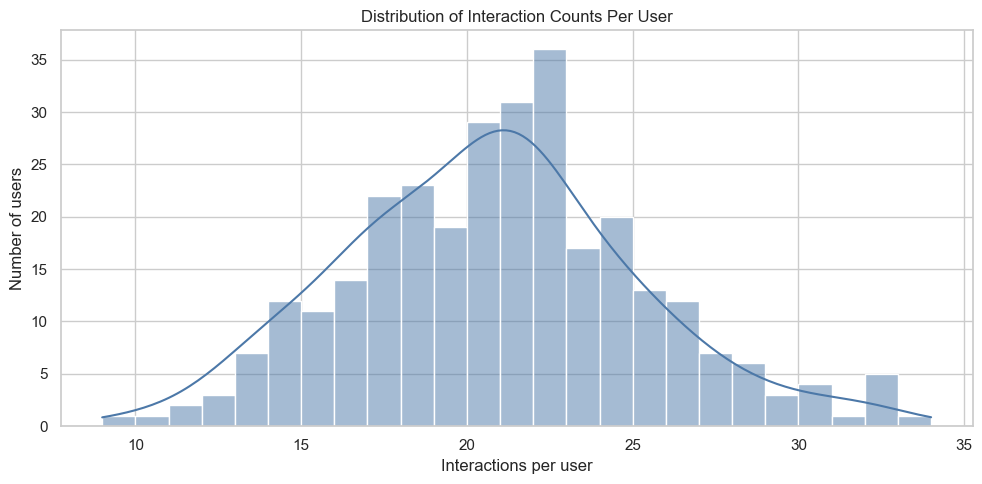

,interaction_count
count,300.000000
mean,20.646667
std,4.421197
min,9.000000
25%,18.000000
50%,21.000000
75%,23.000000
max,34.000000


In [6]:
user_interaction_counts = interactions.groupby("user_id").size().rename("interaction_count")

plt.figure(figsize=(10, 5))
ax = sns.histplot(user_interaction_counts, bins=25, kde=True, color="#4C78A8")
ax.set_title("Distribution of Interaction Counts Per User")
ax.set_xlabel("Interactions per user")
ax.set_ylabel("Number of users")
plt.tight_layout()
plt.show()
display(user_interaction_counts.describe().to_frame())

Most users generate a modest number of events, which mirrors the limited history common in emerging e-commerce datasets. This supports using a hybrid approach because content signals can help when individual Nepali shopper histories are short.

## Product Category Distribution

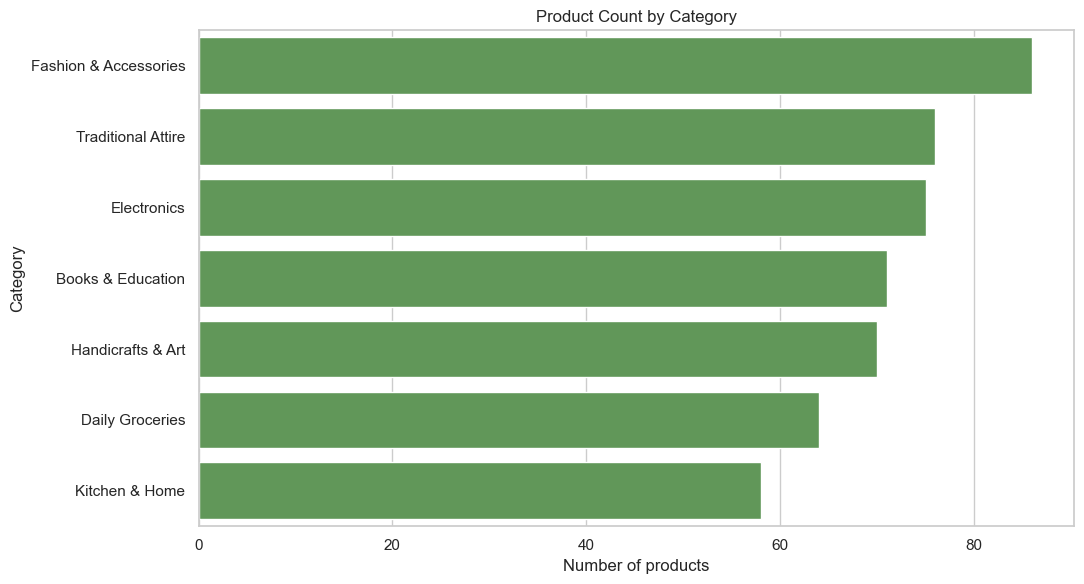

,category,product_count
0,Fashion & Accessories,86
1,Traditional Attire,76
2,Electronics,75
3,Books & Education,71
4,Handicrafts & Art,70
5,Daily Groceries,64
6,Kitchen & Home,58


In [7]:
category_counts = products["category"].value_counts().rename_axis("category").reset_index(name="product_count")

plt.figure(figsize=(11, 6))
ax = sns.barplot(data=category_counts, y="category", x="product_count", color="#59A14F")
ax.set_title("Product Count by Category")
ax.set_xlabel("Number of products")
ax.set_ylabel("Category")
plt.tight_layout()
plt.show()
display(category_counts)

The catalog spans practical shopping categories such as groceries, home goods, fashion, and festival-relevant products. Balanced category coverage matters in Nepal because recommendations should surface both routine purchases and culturally seasonal items.

## Festival Period Flag Distribution

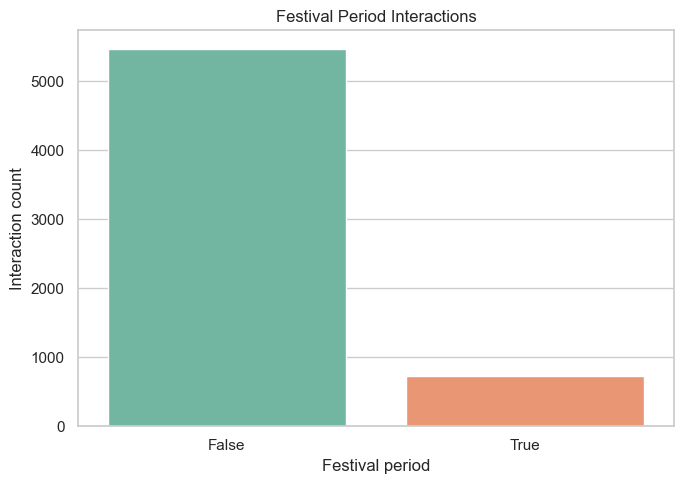

,is_festival_period,interaction_count,share
0,False,5467,0.882628
1,True,727,0.117372


In [8]:
festival_counts = (
    interactions["is_festival_period"].astype(bool).value_counts().rename_axis("is_festival_period").reset_index(name="interaction_count")
)
festival_counts["share"] = festival_counts["interaction_count"] / len(interactions)

plt.figure(figsize=(7, 5))
ax = sns.barplot(data=festival_counts, x="is_festival_period", y="interaction_count", hue="is_festival_period", legend=False)
ax.set_title("Festival Period Interactions")
ax.set_xlabel("Festival period")
ax.set_ylabel("Interaction count")
plt.tight_layout()
plt.show()
display(festival_counts)

Festival-period interactions are important because Nepali shopping behavior changes around Dashain, Tihar, and related seasonal demand. A recommender that recognizes this context can shift attention toward categories that are more relevant during those months.

## New Arrival Flag Distribution

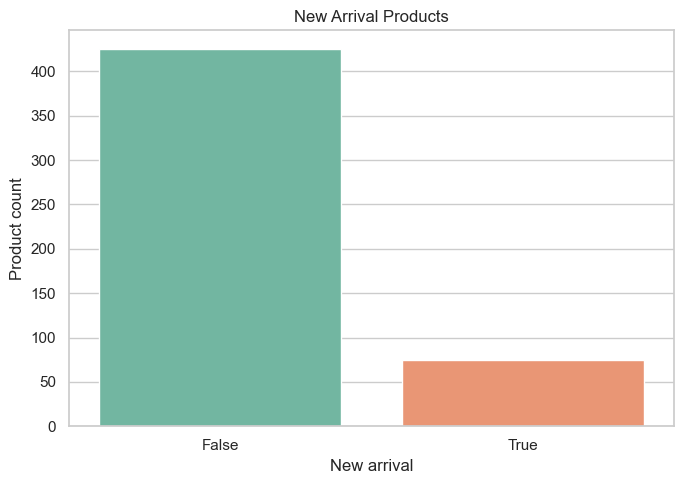

,is_new_arrival,product_count,share
0,False,425,0.85
1,True,75,0.15


In [9]:
new_arrival_counts = (
    products["is_new_arrival"].astype(bool).value_counts().rename_axis("is_new_arrival").reset_index(name="product_count")
)
new_arrival_counts["share"] = new_arrival_counts["product_count"] / len(products)

plt.figure(figsize=(7, 5))
ax = sns.barplot(data=new_arrival_counts, x="is_new_arrival", y="product_count", hue="is_new_arrival", legend=False)
ax.set_title("New Arrival Products")
ax.set_xlabel("New arrival")
ax.set_ylabel("Product count")
plt.tight_layout()
plt.show()
display(new_arrival_counts)

New arrivals provide a freshness signal that helps the system avoid recommending only historically popular products. For Nepali e-commerce, this is especially useful when sellers add festival collections, new electronics, or seasonal essentials that have not yet accumulated interactions.

## Missing Value Summary

In [10]:
def missing_summary(df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    summary = df.isna().sum().rename("missing_count").reset_index().rename(columns={"index": "column"})
    summary["dataset"] = dataset_name
    summary["missing_share"] = summary["missing_count"] / len(df)
    return summary[["dataset", "column", "missing_count", "missing_share"]]

missing_values = pd.concat(
    [
        missing_summary(products, "products"),
        missing_summary(users, "users"),
        missing_summary(interactions, "interactions"),
    ],
    ignore_index=True,
)

display(missing_values)
nonzero_missing = missing_values[missing_values["missing_count"] > 0]
if nonzero_missing.empty:
    print("No missing values were found across products, users, and interactions.")
else:
    print("Columns with missing values:")
    display(nonzero_missing)

,dataset,column,missing_count,missing_share
0,products,product_id,0,0.000000
1,products,name,0,0.000000
2,products,category,0,0.000000
3,products,subcategory,0,0.000000
4,products,brand,0,0.000000
5,products,description,0,0.000000
6,products,price_npr,0,0.000000
7,products,avg_rating,0,0.000000
8,products,rating_count,0,0.000000
9,products,tags,0,0.000000


Columns with missing values:


,dataset,column,missing_count,missing_share
25,interactions,rating,5683,0.917501
